# Noise Visualization — Manual Inspection

Each row = one family, each column = one SNR level.
Goal: visually judge at what noise level each shape becomes unrecognizable.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings, os

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))
warnings.filterwarnings('ignore')

S1_DIR = Path('output/S1')
cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
pts = np.load(S1_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']

cases['snr_float'] = cases['snr'].apply(lambda x: float(x))
case_idx_map = pd.Series(np.arange(len(cases)), index=cases['case_id']).to_dict()

# All families
ALL_FIDS = sorted(cases['family_id'].unique())
print(f'All families: {len(ALL_FIDS)}')
print(ALL_FIDS)

SHORT = {}
for fid in ALL_FIDS:
    row = cases[cases['family_id'] == fid].iloc[0]
    SHORT[fid] = str(row['family_name'])

# Use STRONG variant — strongest feature pattern, easiest to see
all_cases = cases[cases['variant_level'] == 'strong'].copy()
# Null has no 'strong' variant, use 'none'
null_cases = cases[(cases['family_id'] == 'Null') & (cases['variant_level'] == 'none')]
all_cases = pd.concat([all_cases, null_cases], ignore_index=True)
print(f'Loaded {len(all_cases):,} strong-variant cases (+ Null)')

All families: 27
['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'Null']
Loaded 55,620 strong-variant cases (+ Null)


## SNR = 500, 15, 12, 10, 8, 5, 3, 2, 1, 0.5, 0.3, 0.1

Each row is one family (replicate 0).
- **Green border** = clearly recognizable (confidence = 1)
- **Red border** = unrecognizable (confidence = 0)
- Between green and red = **fuzzy zone** (0 < confidence < 1)

Target SNR → Actual SNR:
  500.0 → 500.0000
   15.0 → 15.1759
   12.0 → 11.6574
   10.0 → 10.2171
    8.0 → 7.8483
    5.0 → 4.9466
    3.0 → 2.9188
    2.0 → 1.9651
    1.0 → 1.0162
    0.5 → 0.4920
    0.3 → 0.2903
    0.1 → 0.1011


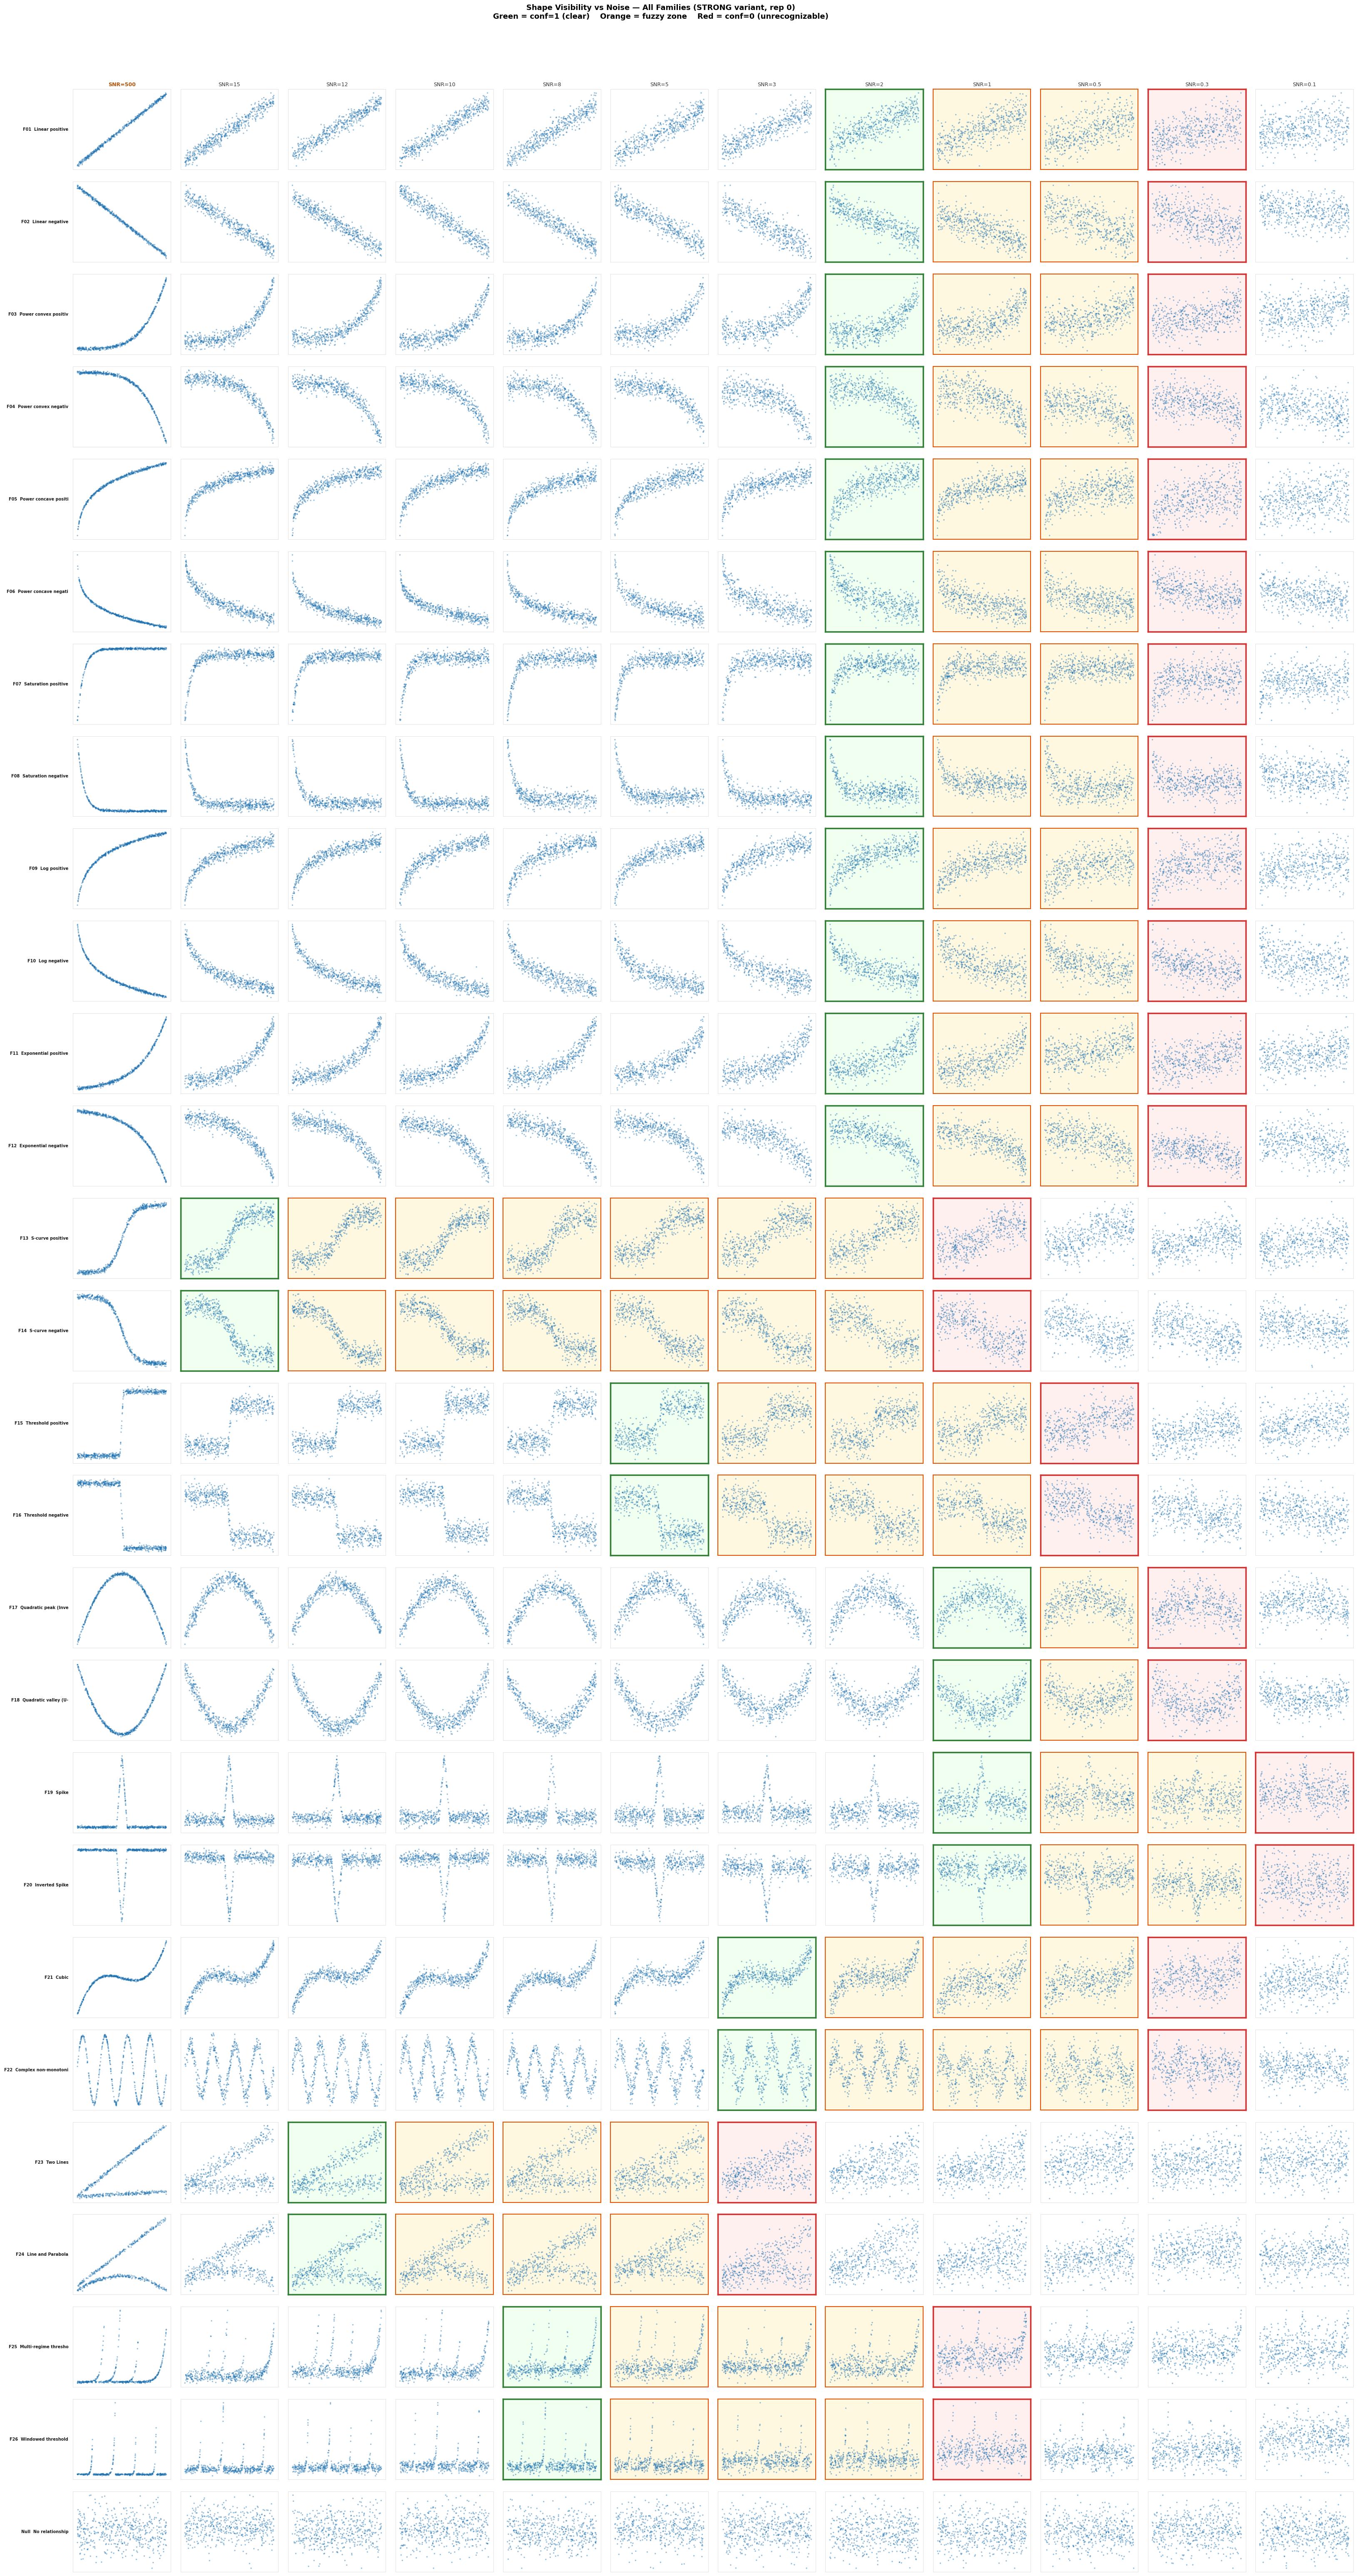

In [9]:
snr_levels = [500.0, 15.0, 12.0, 10.0, 8.0, 5.0, 3.0, 2.0, 1.0, 0.5, 0.3, 0.1]

finite_snrs = all_cases[np.isfinite(all_cases['snr_float'])]['snr_float'].unique()
actual_snrs = []
for s in snr_levels:
    closest = finite_snrs[np.argmin(np.abs(finite_snrs - s))]
    actual_snrs.append(closest)

print('Target SNR → Actual SNR:')
for t, a in zip(snr_levels, actual_snrs):
    print(f'  {t:>5.1f} → {a:.4f}')

# ── Human-annotated boundaries (for STRONG variant) ──
# CLEAR_SNR: shape is clearly recognizable (confidence = 1)
# THRESHOLD_SNR: shape is unrecognizable (confidence = 0)
# Between them = FUZZY ZONE (confidence linearly from 1 → 0)

CLEAR_SNR = {
    'F01': 2.0, 'F02': 2.0,
    'F03': 2.0, 'F04': 2.0, 'F05': 2.0, 'F06': 2.0,
    'F07': 2.0, 'F08': 2.0, 'F09': 2.0, 'F10': 2.0,
    'F11': 2.0, 'F12': 2.0,
    'F13': 5.0, 'F14': 5.0,
    'F15': 5.0, 'F16': 5.0,
    'F17': 1.0, 'F18': 1.0,
    'F19': 1.0, 'F20': 1.0,
    'F21': 3.0, 'F22': 3.0,
    'F23': 8.0, 'F24': 8.0,
    'F25': 8.0, 'F26': 8.0,
}

THRESHOLD_SNR = {
    'F01': 0.3, 'F02': 0.3,
    'F03': 0.3, 'F04': 0.3, 'F05': 0.3, 'F06': 0.3,
    'F07': 0.3, 'F08': 0.3, 'F09': 0.3, 'F10': 0.3,
    'F11': 0.3, 'F12': 0.3,
    'F13': 1.0, 'F14': 1.0,
    'F15': 0.5, 'F16': 0.5,
    'F17': 0.3, 'F18': 0.3,
    'F19': 0.1, 'F20': 0.1,
    'F21': 0.3, 'F22': 0.3,
    'F23': 3.0, 'F24': 3.0,
    'F25': 1.0, 'F26': 1.0,
}

def find_col(target_snr):
    diffs = [abs(s - target_snr) for s in snr_levels]
    return diffs.index(min(diffs))

n_cols = len(actual_snrs)
n_rows = len(ALL_FIDS)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.8 * n_cols, 2.3 * n_rows))

for ri, fid in enumerate(ALL_FIDS):
    fam_cases = all_cases[
        (all_cases['family_id'] == fid) &
        (all_cases['replicate'] == 0)
    ]

    clear_col = find_col(CLEAR_SNR[fid]) if fid in CLEAR_SNR else None
    thresh_col = find_col(THRESHOLD_SNR[fid]) if fid in THRESHOLD_SNR else None

    for ci, snr_val in enumerate(actual_snrs):
        ax = axes[ri, ci]

        match = fam_cases[fam_cases['snr_float'] == snr_val]
        if len(match) > 0:
            cid = match.iloc[0]['case_id']
            idx = case_idx_map[cid]
            x, y = x_all[idx], y_all[idx]
            ax.scatter(x, y, s=6, alpha=0.45, color='#1a6faf', edgecolors='none',
                       rasterized=True)

        ax.set_xticks([])
        ax.set_yticks([])

        # Style: green=CLEAR, red=THRESHOLD, orange=fuzzy zone between them
        is_clear = (clear_col is not None and ci == clear_col)
        is_thresh = (thresh_col is not None and ci == thresh_col)
        is_fuzzy = False
        if clear_col is not None and thresh_col is not None:
            is_fuzzy = (thresh_col < ci < clear_col) or (clear_col < ci < thresh_col)

        if is_clear:
            for spine in ax.spines.values():
                spine.set_linewidth(2.5)
                spine.set_color('#2e7d32')
            ax.set_facecolor('#f0fff0')
        elif is_thresh:
            for spine in ax.spines.values():
                spine.set_linewidth(2.5)
                spine.set_color('#d32f2f')
            ax.set_facecolor('#fff0f0')
        elif is_fuzzy:
            for spine in ax.spines.values():
                spine.set_linewidth(1.5)
                spine.set_color('#E65100')
            ax.set_facecolor('#fff8e1')
        else:
            for spine in ax.spines.values():
                spine.set_linewidth(0.4)
                spine.set_color('#cccccc')

        if ri == 0:
            label = f'SNR={int(snr_levels[ci])}' if snr_levels[ci] >= 1 else f'SNR={snr_levels[ci]}'
            weight = 'bold' if ci == 0 else 'normal'
            ax.set_title(label, fontsize=9, fontweight=weight,
                         color='#333333' if ci > 0 else '#b45309')
        if ci == 0:
            ax.set_ylabel(f'{fid}  {SHORT[fid][:20]}',
                          fontsize=7, fontweight='bold', rotation=0,
                          ha='right', va='center', labelpad=8,
                          color='#1a1a1a')

fig.suptitle('Shape Visibility vs Noise — All Families (STRONG variant, rep 0)\n'
             'Green = conf=1 (clear)    Orange = fuzzy zone    Red = conf=0 (unrecognizable)',
             fontsize=13, fontweight='bold', y=0.998)
plt.subplots_adjust(left=0.08, right=0.995, top=0.965, bottom=0.005,
                    hspace=0.15, wspace=0.10)
plt.savefig('output/S3_polyfit/noise_visual_grid_strong.png', dpi=150, bbox_inches='tight')
plt.show()

## Fuzzy Zone — MIC Thresholds per Family

Human-annotated SNR boundaries → mapped to **MIC values**:
- At **CLEAR_SNR**: shape clearly visible → MIC at this point = **upper bound** (conf = 1)
- At **THRESHOLD_SNR**: shape unrecognizable → MIC at this point = **lower bound** (conf = 0)

The per-family MIC fuzzy range replaces the single hard threshold (MIC ≥ 0.8).

In [10]:
# ── Map SNR boundaries → MIC values ──
metrics = pd.read_parquet(Path('output/S2') / 'metrics_full.parquet')
df = cases.merge(metrics[['case_id', 'MIC']], on='case_id')

# Use strong variant (matching the visual inspection)
strong = df[df['variant_level'] == 'strong'].copy()
null = df[df['family_id'] == 'Null'].copy()
strong = pd.concat([strong, null], ignore_index=True)

# Compute mean MIC per (family, SNR)
agg = strong.groupby(['family_id', 'snr_float'])['MIC'].mean()

print('=' * 85)
print('  FUZZY CALIBRATION — Per-Family MIC Thresholds (strong variant)')
print('=' * 85)
print()
print(f'{"Family":<6} {"Name":<25} {"CLEAR":>6} {"THRESH":>7}  '
      f'{"MIC@CLEAR":>10} {"MIC@THRESH":>11}  {"MIC Fuzzy Zone":>16}')
print(f'{"":6} {"":25} {"SNR":>6} {"SNR":>7}  '
      f'{"(conf=1)":>10} {"(conf=0)":>11}  {"":>16}')
print('-' * 85)

fuzzy_rows = []
for fid in [f'F{i:02d}' for i in range(1, 27)]:
    c_snr = CLEAR_SNR[fid]
    t_snr = THRESHOLD_SNR[fid]
    name = SHORT[fid][:25]

    fam_agg = agg[fid]
    snrs = fam_agg.index.values

    # Find closest SNR in data
    c_actual = snrs[np.argmin(np.abs(snrs - c_snr))]
    t_actual = snrs[np.argmin(np.abs(snrs - t_snr))]
    mic_clear = fam_agg[c_actual]
    mic_thresh = fam_agg[t_actual]

    fuzzy_rows.append({
        'family_id': fid, 'name': name,
        'clear_snr': c_snr, 'thresh_snr': t_snr,
        'mic_clear': mic_clear, 'mic_thresh': mic_thresh,
    })

    print(f'{fid:<6} {name:<25} {c_snr:>6.1f} {t_snr:>7.1f}  '
          f'{mic_clear:>10.3f} {mic_thresh:>11.3f}  '
          f'{mic_thresh:>6.3f} – {mic_clear:.3f}')

print('-' * 85)

fuzzy_df = pd.DataFrame(fuzzy_rows)
print()
print('── Summary statistics ──')
print(f'  MIC upper bound (conf=1): {fuzzy_df["mic_clear"].min():.3f} – {fuzzy_df["mic_clear"].max():.3f}  '
      f'(mean {fuzzy_df["mic_clear"].mean():.3f})')
print(f'  MIC lower bound (conf=0): {fuzzy_df["mic_thresh"].min():.3f} – {fuzzy_df["mic_thresh"].max():.3f}  '
      f'(mean {fuzzy_df["mic_thresh"].mean():.3f})')
print()
print('── Fuzzy confidence formula (per-family, post-classification) ──')
print()
print('  After the tree classifies a case as family F:')
print('    MIC_upper = MIC@CLEAR[F]     (above → conf = 1)')
print('    MIC_lower = MIC@THRESH[F]    (below → conf = 0)')
print('    conf = clamp((MIC - MIC_lower) / (MIC_upper - MIC_lower), 0, 1)')
print()
print('  Example: case classified as F01, MIC = 0.45')
print(f'    MIC_upper = {fuzzy_df.loc[0,"mic_clear"]:.3f}, MIC_lower = {fuzzy_df.loc[0,"mic_thresh"]:.3f}')
mic_ex = 0.45
conf_ex = max(0, min(1, (mic_ex - fuzzy_df.loc[0,'mic_thresh']) / (fuzzy_df.loc[0,'mic_clear'] - fuzzy_df.loc[0,'mic_thresh'])))
print(f'    conf = ({mic_ex} - {fuzzy_df.loc[0,"mic_thresh"]:.3f}) / ({fuzzy_df.loc[0,"mic_clear"]:.3f} - {fuzzy_df.loc[0,"mic_thresh"]:.3f}) = {conf_ex:.2f}')

  FUZZY CALIBRATION — Per-Family MIC Thresholds (strong variant)

Family Name                       CLEAR  THRESH   MIC@CLEAR  MIC@THRESH    MIC Fuzzy Zone
                                    SNR     SNR    (conf=1)    (conf=0)                  
-------------------------------------------------------------------------------------
F01    Linear positive              2.0     0.3       0.635       0.286   0.286 – 0.635
F02    Linear negative              2.0     0.3       0.642       0.294   0.294 – 0.642
F03    Power convex positive        2.0     0.3       0.490       0.261   0.261 – 0.490
F04    Power convex negative        2.0     0.3       0.508       0.259   0.259 – 0.508
F05    Power concave positive       2.0     0.3       0.518       0.268   0.268 – 0.518
F06    Power concave negative       2.0     0.3       0.503       0.265   0.265 – 0.503
F07    Saturation positive          2.0     0.3       0.350       0.224   0.224 – 0.350
F08    Saturation negative          2.0     0.3     